In [1]:
# =============================================================================
# Colour space conversion tests — GPU vs CPU
# Copy each cell block into a Jupyter Notebook cell.
# =============================================================================

# ── Cell 1: Imports & setup ──────────────────────────────────────────────────
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import colour_spaces as cpu   # original file you sent
import colour_spaces_gpu as gpu  # new PyTorch file

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on: {DEVICE}")

Running on: cuda


In [2]:
# Tolerances
ABS_TOL   = 1e-3   # for float spaces (DKL, YOG, XYZ, LMS …)
UINT8_TOL = 2      # ±2 levels for uint8 round-trips (rounding is expected)


# ── Cell 2: Create a synthetic batch of images ───────────────────────────────
def make_test_batch(batch=4, h=64, w=64, seed=42):
    """
    Returns:
        np_imgs  : list of (H, W, 3) uint8 numpy arrays  — for the CPU code
        gpu_batch: (B, 3, H, W) uint8 torch tensor on DEVICE — for the GPU code
    """
    rng = np.random.default_rng(seed)
    imgs = []

    # 1. random noise image
    imgs.append(rng.integers(0, 256, (h, w, 3), dtype=np.uint8))

    # 2. flat grey
    grey = np.full((h, w, 3), 128, dtype=np.uint8)
    imgs.append(grey)

    # 3. smooth gradient (tests boundary behaviour)
    grad = np.zeros((h, w, 3), dtype=np.uint8)
    grad[:, :, 0] = np.linspace(0, 255, w, dtype=np.uint8)[None, :]
    grad[:, :, 1] = np.linspace(0, 255, h, dtype=np.uint8)[:, None]
    grad[:, :, 2] = 128
    imgs.append(grad)

    # 4. primary/secondary colour blocks
    blocks = np.zeros((h, w, 3), dtype=np.uint8)
    hw = h // 2
    blocks[:hw, :hw] = [255,   0,   0]   # red
    blocks[:hw, hw:] = [  0, 255,   0]   # green
    blocks[hw:, :hw] = [  0,   0, 255]   # blue
    blocks[hw:, hw:] = [255, 255,   0]   # yellow
    imgs.append(blocks)

    # Extend to requested batch size by cycling
    np_imgs = [imgs[i % len(imgs)] for i in range(batch)]

    # Build GPU tensor  (B, 3, H, W)
    stack = np.stack(np_imgs, axis=0)                    # (B, H, W, 3)
    gpu_batch = torch.from_numpy(stack).permute(0, 3, 1, 2).to(DEVICE)  # (B,3,H,W)

    return np_imgs, gpu_batch


np_imgs, gpu_batch = make_test_batch()
print(f"CPU images: {len(np_imgs)} × {np_imgs[0].shape}  dtype={np_imgs[0].dtype}")
print(f"GPU tensor: {tuple(gpu_batch.shape)}  dtype={gpu_batch.dtype}  device={gpu_batch.device}")

CPU images: 4 × (64, 64, 3)  dtype=uint8
GPU tensor: (4, 3, 64, 64)  dtype=torch.uint8  device=cuda:0


In [3]:
# ── Cell 3: Helper — compare GPU result to CPU result ───────────────────────
def gpu_to_np_hwc(t: torch.Tensor) -> np.ndarray:
    """(B,C,H,W) float or uint8 tensor → list of (H,W,C) numpy arrays."""
    t = t.detach().cpu()
    if t.dtype == torch.uint8:
        t = t.float()
    return [t[i].permute(1, 2, 0).numpy() for i in range(t.shape[0])]


def compare(test_name, cpu_results, gpu_results_t, tol=ABS_TOL):
    """
    cpu_results  : list of (H,W,C) numpy arrays
    gpu_results_t: (B,C,H,W) torch tensor
    """
    gpu_results = gpu_to_np_hwc(gpu_results_t)
    errors = []
    for i, (c, g) in enumerate(zip(cpu_results, gpu_results)):
        c = c.astype(np.float32)
        g = g.astype(np.float32)
        mae  = np.abs(c - g).mean()
        maxe = np.abs(c - g).max()
        errors.append((mae, maxe))

    mae_mean  = np.mean([e[0] for e in errors])
    max_error = np.max([e[1]  for e in errors])
    status = "✅ PASS" if max_error <= tol else "❌ FAIL"
    print(f"{status}  {test_name:<30}  MAE={mae_mean:.6f}  MAX={max_error:.6f}  (tol={tol})")
    return errors

In [29]:
#gpu_dkl[0].cpu().numpy().transpose(1, 2, 0)

In [31]:
gpu_dkl[0].T.shape

/tmp/ipykernel_41085/3932957118.py:1: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4416.)
  gpu_dkl[0].T.shape


torch.Size([64, 64, 3])

In [30]:
#cpu_dkl[0]

In [39]:
import importlib
importlib.reload(gpu)

# ── Cell 4: Matrix-based conversions (linear, tight tolerance) ───────────────
print("=" * 65)
print("Matrix-based colour spaces")
print("=" * 65)

# --- RGB → DKL ---
cpu_dkl  = [cpu.rgb2dkl(img) for img in np_imgs]
gpu_dkl  = gpu.rgb2dkl(gpu_batch)
compare("rgb2dkl", cpu_dkl, gpu_dkl)

# --- DKL → RGB (uint8 round-trip) ---
cpu_dkl2rgb = [cpu.dkl2rgb(d) for d in cpu_dkl]
gpu_dkl2rgb = gpu.dkl2rgb(gpu_dkl)
compare("dkl2rgb (round-trip uint8)", cpu_dkl2rgb, gpu_dkl2rgb, tol=UINT8_TOL)

# --- RGB → YOG ---
cpu_yog = [cpu.rgb2yog(img) for img in np_imgs]
gpu_yog = gpu.rgb2yog(gpu_batch)
compare("rgb2yog", cpu_yog, gpu_yog)

# --- YOG → RGB (uint8 round-trip) ---
cpu_yog2rgb = [cpu.yog2rgb(y) for y in cpu_yog]
gpu_yog2rgb = gpu.yog2rgb(gpu_yog)
compare("yog2rgb (round-trip uint8)", cpu_yog2rgb, gpu_yog2rgb, tol=UINT8_TOL)

# --- RGB → XYZ ---
cpu_xyz = [cpu.rgb2xyz(img) for img in np_imgs]
gpu_xyz = gpu.rgb2xyz(gpu_batch)
compare("rgb2xyz", cpu_xyz, gpu_xyz)

# --- XYZ → LMS ---
cpu_lms = [cpu.xyz2lms(img) for img in cpu_xyz]
gpu_lms = gpu.xyz2lms(gpu_xyz)
compare("xyz2lms", cpu_lms, gpu_lms)

# --- RGB → LMS ---
cpu_lms = [cpu.rgb2lms(img) for img in np_imgs]
gpu_lms = gpu.rgb2lms(gpu_batch)
compare("rgb2lms", cpu_lms, gpu_lms)

# --- LMS → RGB (uint8 round-trip) ---
cpu_lms2rgb = [cpu.lms2rgb(l) for l in cpu_lms]
gpu_lms2rgb = gpu.lms2rgb(gpu_lms)
compare("lms2rgb (round-trip uint8)", cpu_lms2rgb, gpu_lms2rgb, tol=UINT8_TOL)

# --- RGB [0,1] → LMS [0,1] ---
cpu_lms01 = [cpu.rgb2lms01(img) for img in np_imgs]
gpu_lms01 = gpu.rgb2lms01(gpu_batch)
compare("rgb2lms01", cpu_lms01, gpu_lms01)

Matrix-based colour spaces
✅ PASS  rgb2dkl                         MAE=0.000000  MAX=0.000000  (tol=0.001)
✅ PASS  dkl2rgb (round-trip uint8)      MAE=0.167623  MAX=1.000000  (tol=2)
✅ PASS  rgb2yog                         MAE=0.000000  MAX=0.000000  (tol=0.001)
✅ PASS  yog2rgb (round-trip uint8)      MAE=0.101990  MAX=1.000000  (tol=2)
✅ PASS  rgb2xyz                         MAE=0.000000  MAX=0.000000  (tol=0.001)
✅ PASS  xyz2lms                         MAE=0.000000  MAX=0.000001  (tol=0.001)
✅ PASS  rgb2lms                         MAE=0.000000  MAX=0.000001  (tol=0.001)
✅ PASS  lms2rgb (round-trip uint8)      MAE=0.195516  MAX=1.000000  (tol=2)
✅ PASS  rgb2lms01                       MAE=0.000000  MAX=0.000000  (tol=0.001)


[(np.float32(3.7893262e-08), np.float32(2.3841858e-07)),
 (np.float32(3.973643e-08), np.float32(5.9604645e-08)),
 (np.float32(2.927421e-08), np.float32(1.7881393e-07)),
 (np.float32(3.7252903e-09), np.float32(2.9802322e-08))]

In [35]:
# ── Cell 7: DKL [0,1] round-trip ────────────────────────────────────────────
print()
print("=" * 65)
print("Normalised [0,1] round-trips")
print("=" * 65)

cpu_dkl01 = [cpu.rgb2dkl01(img) for img in np_imgs]
gpu_dkl01 = gpu.rgb2dkl01(gpu_batch)
compare("rgb2dkl01", cpu_dkl01, gpu_dkl01)

cpu_dkl012rgb = [cpu.dkl012rgb(d) for d in cpu_dkl01]
gpu_dkl012rgb = gpu.dkl012rgb(gpu_dkl01)
compare("dkl012rgb (uint8 round-trip)", cpu_dkl012rgb, gpu_dkl012rgb, tol=UINT8_TOL)

cpu_yog01 = [cpu.rgb2yog01(img) for img in np_imgs]
gpu_yog01 = gpu.rgb2yog01(gpu_batch)
compare("rgb2yog01", cpu_yog01, gpu_yog01)

cpu_yog012rgb = [cpu.yog012rgb(y) for y in cpu_yog01]
gpu_yog012rgb = gpu.yog012rgb(gpu_yog01)
compare("yog012rgb (uint8 round-trip)", cpu_yog012rgb, gpu_yog012rgb, tol=UINT8_TOL)

cpu_yog012rgb01 = [cpu.yog012rgb01(y) for y in cpu_yog01]
gpu_yog012rgb01 = gpu.yog012rgb01(gpu_yog01)
compare("yog012rgb01 (round-trip)", cpu_yog012rgb01, gpu_yog012rgb01, tol=ABS_TOL)


Normalised [0,1] round-trips
✅ PASS  rgb2dkl01                       MAE=0.000000  MAX=0.000000  (tol=0.001)
✅ PASS  dkl012rgb (uint8 round-trip)    MAE=0.211283  MAX=1.000000  (tol=2)
✅ PASS  rgb2yog01                       MAE=0.000000  MAX=0.000000  (tol=0.001)
✅ PASS  yog012rgb (uint8 round-trip)    MAE=0.127787  MAX=1.000000  (tol=2)
✅ PASS  yog012rgb01 (round-trip)        MAE=0.000000  MAX=0.000000  (tol=0.001)


[(np.float32(3.1371883e-08), np.float32(1.7881393e-07)),
 (np.float32(0.0), np.float32(0.0)),
 (np.float32(3.01067e-08), np.float32(1.1920929e-07)),
 (np.float32(0.0), np.float32(0.0))]

In [40]:
# ── Cell 5: HSV (pure-PyTorch vs cv2) ───────────────────────────────────────
print()
print("=" * 65)
print("HSV  (cv2 on CPU  vs  pure-PyTorch on GPU)")
print("=" * 65)

# cv2 HSV: H∈[0,180], S/V∈[0,255]  → normalised to [0,1] by cpu code
cpu_hsv = [cpu.rgb2hsv01(img) for img in np_imgs]
gpu_hsv = gpu.rgb2hsv01(gpu_batch)
compare("rgb2hsv01", cpu_hsv, gpu_hsv, tol=5e-3)   # cv2 uses uint8 quantisation

# HSV → RGB round-trip
cpu_hsv2rgb = [cpu.hsv012rgb(h) for h in cpu_hsv]
gpu_hsv2rgb = gpu.hsv012rgb(gpu_hsv)
compare("hsv012rgb (round-trip uint8)", cpu_hsv2rgb, gpu_hsv2rgb, tol=UINT8_TOL)


HSV  (cv2 on CPU  vs  pure-PyTorch on GPU)
❌ FAIL  rgb2hsv01                       MAE=0.000532  MAX=0.998965  (tol=0.005)
❌ FAIL  hsv012rgb (round-trip uint8)    MAE=0.257772  MAX=10.000000  (tol=2)


[(np.float32(0.55566406), np.float32(10.0)),
 (np.float32(0.0), np.float32(0.0)),
 (np.float32(0.4754232), np.float32(6.0)),
 (np.float32(0.0), np.float32(0.0))]

In [41]:
# ── Cell 6: LAB / LCH  (pure-PyTorch vs cv2) ────────────────────────────────
print()
print("=" * 65)
print("LAB / LCH  (cv2 on CPU  vs  pure-PyTorch on GPU)")
print("=" * 65)

# cv2 LAB uses 8-bit quantisation internally, so we allow a looser tolerance
LAB_TOL = 1.5   # LAB units

cpu_lab = [cpu.rgb2opponency(img, 'lab') for img in np_imgs]
gpu_lab = gpu.rgb2opponency(gpu_batch, 'lab')
compare("rgb2lab (opponency)", cpu_lab, gpu_lab, tol=LAB_TOL)

# LAB → LCH
cpu_lch = [cpu.lab2lch(l) for l in cpu_lab]
gpu_lch = gpu.lab2lch(gpu_lab)
compare("lab2lch", cpu_lch, gpu_lch, tol=LAB_TOL)

# LCH → LAB round-trip
cpu_lch2lab = [cpu.lch2lab(lch) for lch in cpu_lch]
gpu_lch2lab = gpu.lch2lab(gpu_lch)
compare("lch2lab (round-trip)", cpu_lch2lab, gpu_lch2lab, tol=LAB_TOL)

# LCH [0,1] normalisation
cpu_lch01 = [cpu.lab2lch01(l) for l in cpu_lab]
gpu_lch01 = gpu.lab2lch01(gpu_lab)
compare("lab2lch01", cpu_lch01, gpu_lch01, tol=1e-2)


LAB / LCH  (cv2 on CPU  vs  pure-PyTorch on GPU)
❌ FAIL  rgb2lab (opponency)             MAE=8.343557  MAX=39.747044  (tol=1.5)
❌ FAIL  lab2lch                         MAE=17.647963  MAX=359.003418  (tol=1.5)
❌ FAIL  lch2lab (round-trip)            MAE=8.343557  MAX=39.747028  (tol=1.5)
❌ FAIL  lab2lch01                       MAE=0.093980  MAX=0.997232  (tol=0.01)


[(np.float32(0.10604391), np.float32(0.9915756)),
 (np.float32(0.158689), np.float32(0.25)),
 (np.float32(0.11117041), np.float32(0.9972318)),
 (np.float32(1.7506381e-05), np.float32(7.83205e-05))]

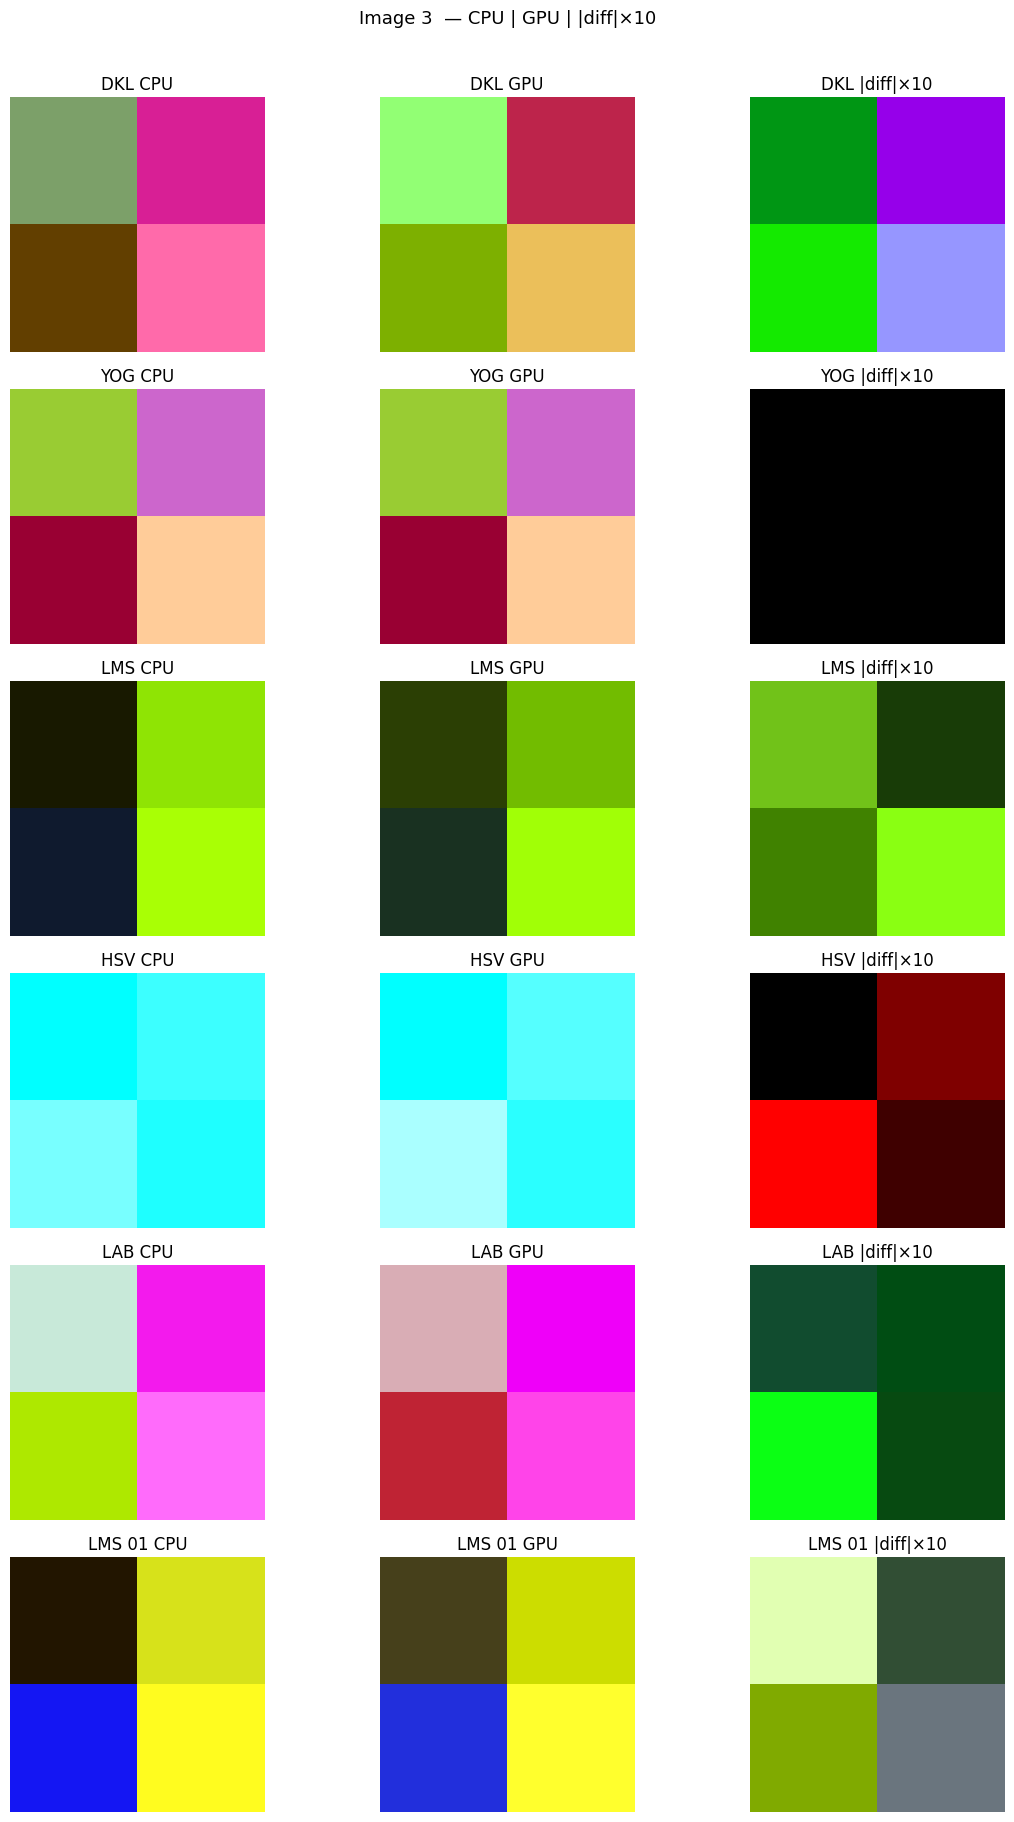

In [8]:
# ── Cell 8: Visual comparison — one image, all spaces ───────────────────────
def show_comparison(img_idx=3):
    """
    Show side-by-side CPU vs GPU outputs for every colour space.
    img_idx=3 is the colour-block image — most informative visually.
    """
    spaces = [
        ("DKL",    cpu_dkl,    gpu_dkl),
        ("YOG",    cpu_yog,    gpu_yog),
        ("LMS",    cpu_lms,    gpu_lms),
        ("HSV",    cpu_hsv,    gpu_hsv),
        ("LAB",    cpu_lab,    gpu_lab),
        ("LMS 01", cpu_lms01,  gpu_lms01),
    ]

    n = len(spaces)
    fig, axes = plt.subplots(n, 3, figsize=(12, 3 * n))
    fig.suptitle(f"Image {img_idx}  — CPU | GPU | |diff|×10", fontsize=13, y=1.01)

    for row, (name, cpu_list, gpu_t) in enumerate(spaces):
        cpu_img = cpu_list[img_idx].astype(np.float32)
        gpu_img = gpu_to_np_hwc(gpu_t)[img_idx].astype(np.float32)

        # Normalise to [0,1] for display
        def norm(a):
            lo, hi = a.min(), a.max()
            return (a - lo) / (hi - lo + 1e-8)

        diff = np.abs(cpu_img - gpu_img) * 10

        axes[row, 0].imshow(norm(cpu_img)); axes[row, 0].set_title(f"{name} CPU")
        axes[row, 1].imshow(norm(gpu_img)); axes[row, 1].set_title(f"{name} GPU")
        axes[row, 2].imshow(norm(diff));    axes[row, 2].set_title(f"{name} |diff|×10")
        for ax in axes[row]: ax.axis("off")

    plt.tight_layout()
    plt.show()

show_comparison(img_idx=3)

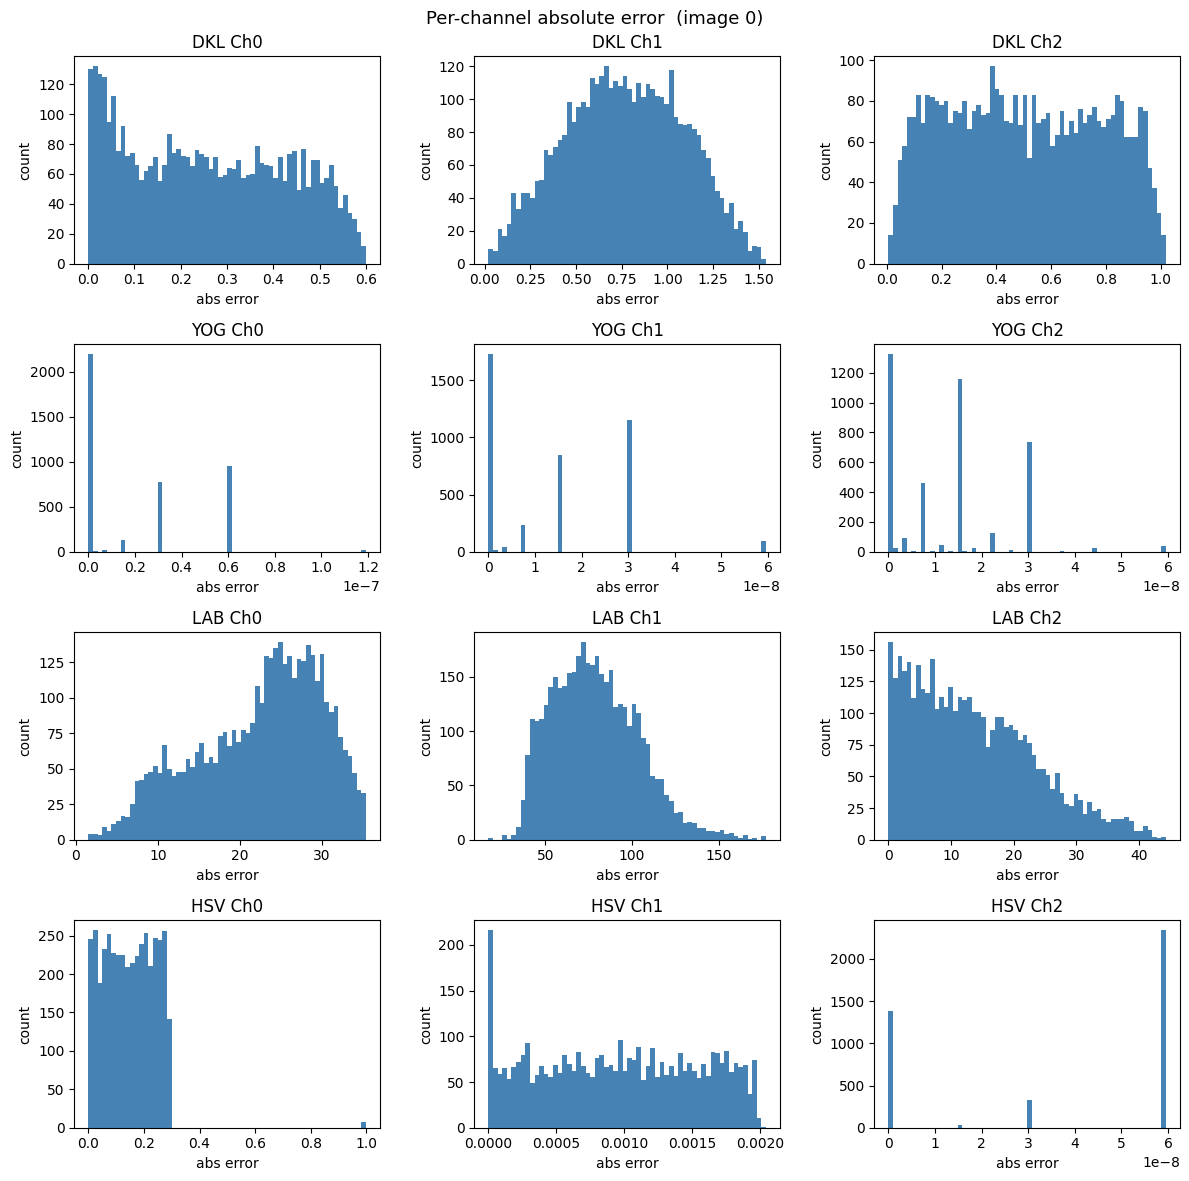


get_max_lightness
  ✅  space=None    cpu=255  gpu=255.0
  ✅  space=lab     cpu=100  gpu=100.0
  ✅  space=dkl     cpu=2  gpu=2.0


In [9]:
# ── Cell 9: Per-channel error histograms ─────────────────────────────────────
def plot_error_histograms(img_idx=0):
    """
    Per-channel absolute error histograms for DKL, YOG, LAB, HSV.
    """
    tests = [
        ("DKL",  cpu_dkl,  gpu_dkl),
        ("YOG",  cpu_yog,  gpu_yog),
        ("LAB",  cpu_lab,  gpu_lab),
        ("HSV",  cpu_hsv,  gpu_hsv),
    ]
    ch_names = ["Ch0", "Ch1", "Ch2"]
    fig, axes = plt.subplots(len(tests), 3, figsize=(12, 3 * len(tests)))
    fig.suptitle(f"Per-channel absolute error  (image {img_idx})", fontsize=13)

    for row, (name, cpu_list, gpu_t) in enumerate(tests):
        c = cpu_list[img_idx].astype(np.float32)
        g = gpu_to_np_hwc(gpu_t)[img_idx].astype(np.float32)
        err = np.abs(c - g)
        for ch in range(3):
            axes[row, ch].hist(err[:, :, ch].ravel(), bins=60, color="steelblue", edgecolor="none")
            axes[row, ch].set_title(f"{name} {ch_names[ch]}")
            axes[row, ch].set_xlabel("abs error"); axes[row, ch].set_ylabel("count")

    plt.tight_layout()
    plt.show()

plot_error_histograms(img_idx=0)


# ── Cell 10: get_max_lightness smoke-test ────────────────────────────────────
print()
print("=" * 65)
print("get_max_lightness")
print("=" * 65)
for space in [None, 'lab', 'dkl']:
    cpu_val = cpu.get_max_lightness(space)
    gpu_val = gpu.get_max_lightness(space)
    ok = "✅" if cpu_val == gpu_val else "❌"
    print(f"  {ok}  space={str(space):<6}  cpu={cpu_val}  gpu={gpu_val}")